In [1]:
#import imageio
import matplotlib
matplotlib.use('Agg')
import matplotlib.image as mpimg
import matplotlib.pylab as plt
import numpy as np
from   PIL import Image, ImageFilter#, ImageDraw, ImageFont
#from   PIL.ImageChops import add, difference, multiply, screen, subtract
#import PIL.ImageStat as stat
#from   scipy import misc
#from   scipy.ndimage import affine_transform, zoom
from   skimage import color, data, exposure, img_as_float, viewer
from   skimage.io import (
    imread, imread_collection, imsave, imshow, imshow_collection, show)
#from   skimage.transform import SimilarityTransform, swirl, warp
#from   skimage.util import invert, montage, random_noise

%matplotlib inline

In [2]:
IMG = '../../../images'

In [3]:
lena = mpimg.imread(f'{IMG}/lena.jpg')
print(lena[0, 40])

[180  76  83]


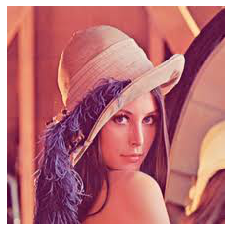

In [4]:
plt.imshow(lena)
plt.axis('off');

In [5]:
print(lena[10:13, 20:23, 0:1])

[[[232]
  [234]
  [231]]

 [[232]
  [236]
  [233]]

 [[234]
  [236]
  [234]]]


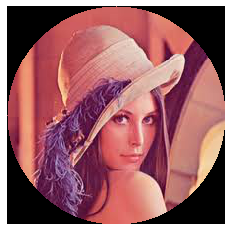

In [6]:
lx, ly, _ = lena.shape
X, Y = np.ogrid[0:lx, 0:ly]
circle_mask = (X - lx/2)**2 + (Y - ly/2)**2 > lx*ly/4
lena_copy = lena.copy()
lena_copy[circle_mask, :] = 0
plt.imshow(lena_copy)
plt.axis('off');

In [7]:
FACES = (
    '/Users/dsatterthwaite/repos/scripts-analytics/faces/images/resized')

In [8]:
def blend(im1, im2):
    i = 1
    plt.figure(figsize=(18, 15))
    out = None
    for alpha in np.linspace(0, 1, 21):
        halfway = 0.5
        if alpha == halfway:
            out = (1 - alpha)*im1 + alpha*im2
        else:
            plt.subplot(4, 5, i)
            plt.imshow((1 - alpha)*im1 + alpha*im2)
            plt.axis('off')
            i += 1
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.show()
    return out

In [9]:
sean = mpimg.imread(f'{FACES}/snelson2.jpg') / 255
matt = mpimg.imread(f'{FACES}/mnickerson2.jpg') / 255

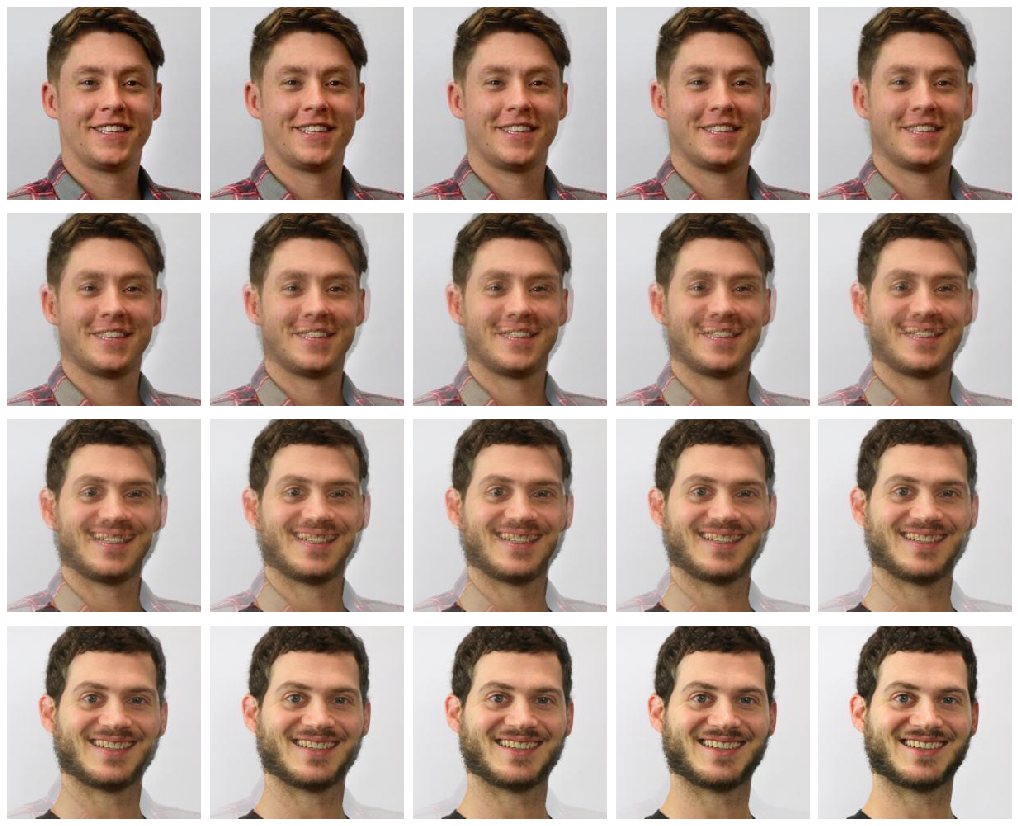

In [10]:
blended = blend(sean, matt)

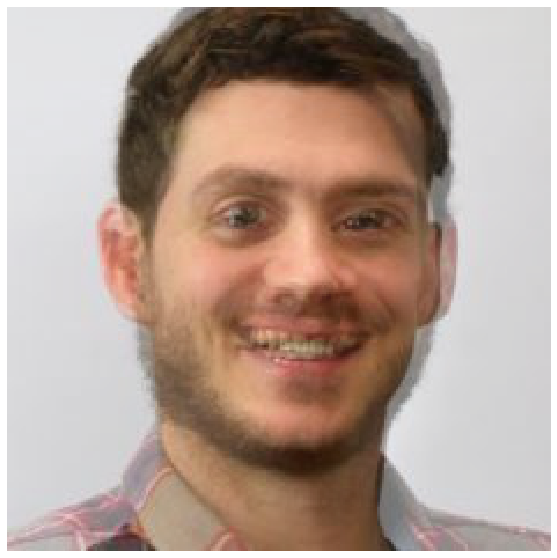

In [11]:
plt.figure(figsize=(10, 10))
plt.imshow(blended)
plt.axis('off');

In [12]:
im = Image.fromarray(np.uint8(blended * 255))
im = im.filter(ImageFilter.BLUR)
im = im.filter(ImageFilter.SHARPEN)
im.show()

## Using PIL

In [24]:
im = Image.open(f'{IMG}/parrot.png')
print(im.width, im.height, im.mode, im.format)

453 340 RGB PNG


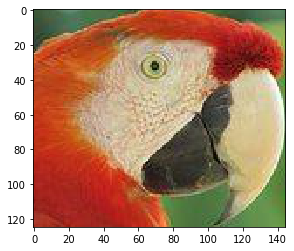

In [25]:
cropped = im.crop((175, 75, 320, 200)) # l, r, t, b
#cropped.show()
plt.imshow(cropped);

### Resizing

107 105


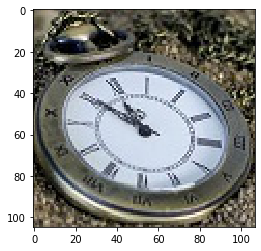

In [3]:
im = Image.open(f'{IMG}/clock.jpg')
print(im.width, im.height)
#im.show()
plt.imshow(im);

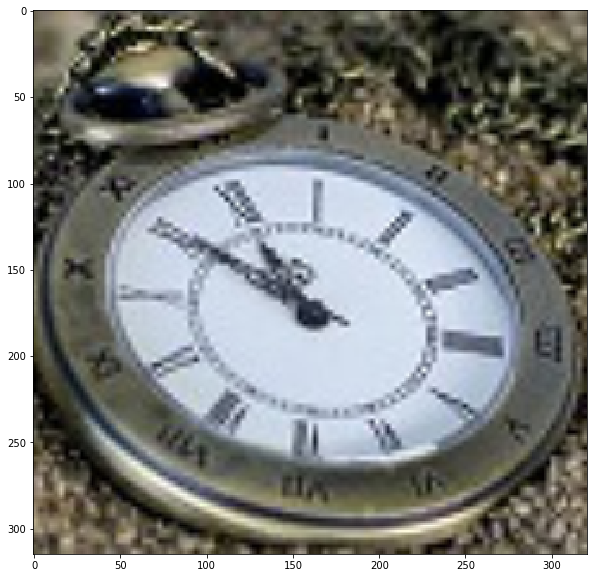

In [4]:
im_large = im.resize((3*im.width, 3*im.height), Image.BILINEAR)
plt.figure(figsize=(10, 10))
plt.imshow(im_large);

720 540


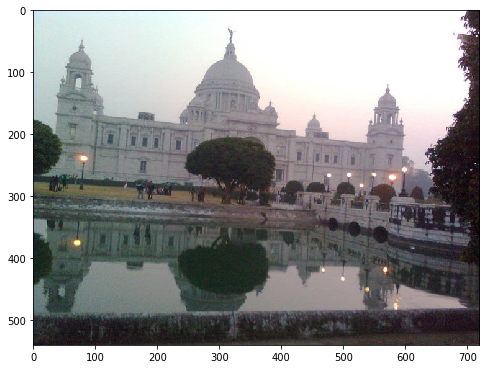

In [5]:
im = Image.open(f'{IMG}/victoria_memorial.png')
print(im.width, im.height)
plt.figure(figsize=(8, 8))
plt.imshow(im);

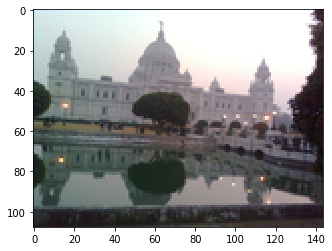

In [6]:
im_small = im.resize((im.width // 5, im.height // 5), Image.ANTIALIAS)
plt.imshow(im_small);

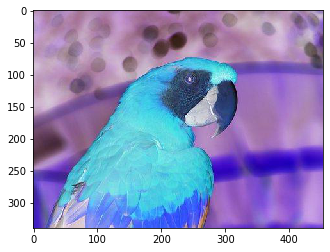

In [3]:
im = Image.open(f'{IMG}/parrot.png')
im_neg = im.point(lambda x: 255 - x)
plt.imshow(im_neg);

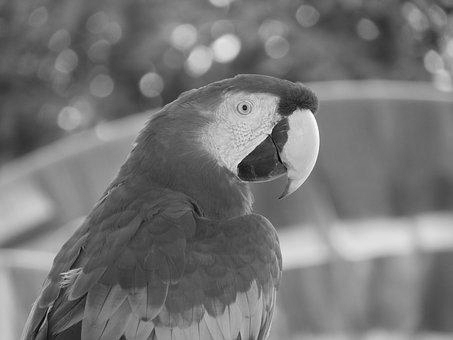

In [4]:
im_g = im.convert('L')
im_g

### Grey-level Transforms
Log: Used to compress unique values but maintain good contrast

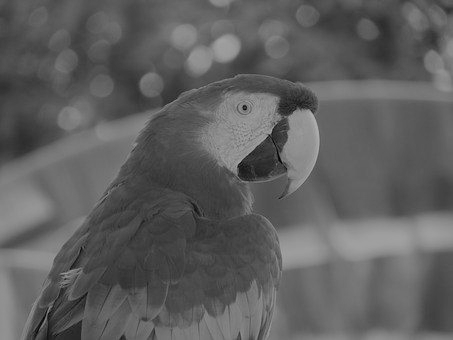

In [5]:
im_g.point(lambda x: 255*np.log(1 + x/255))

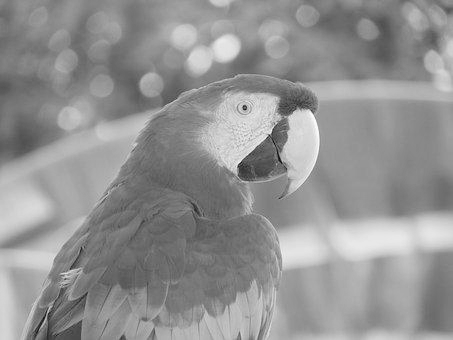

In [6]:
im_g.point(lambda x: 255 * (x / 255)**0.7)

## Geometric Transforms

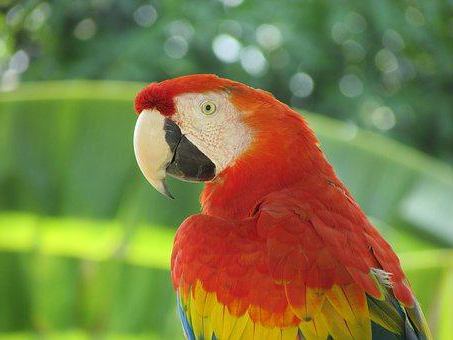

In [7]:
im.transpose(Image.FLIP_LEFT_RIGHT)

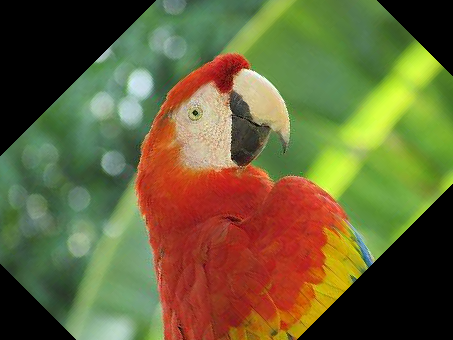

In [8]:
im45 = im.rotate(45)
im45

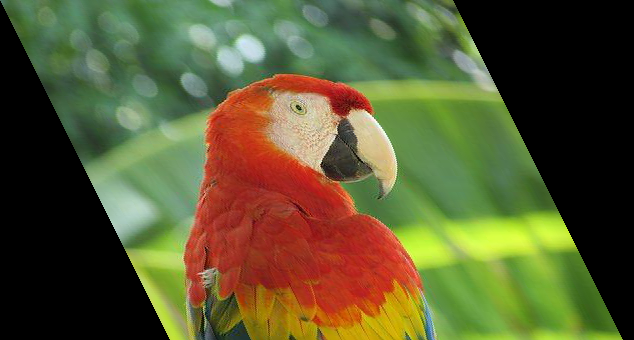

In [9]:
im.transform((int(1.4 * im.width), im.height),
             Image.AFFINE,
             data=[1, -0.5, 0, 0, 1, 0])

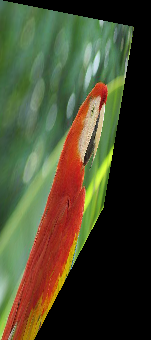

In [11]:
params = [1, 0.1, 0, -0.1, 0.5, 0, -0.005, -0.001]
im1 = im.transform((im.width // 3, im.height),
                   Image.PERSPECTIVE,
                   params,
                   Image.BICUBIC)
im1